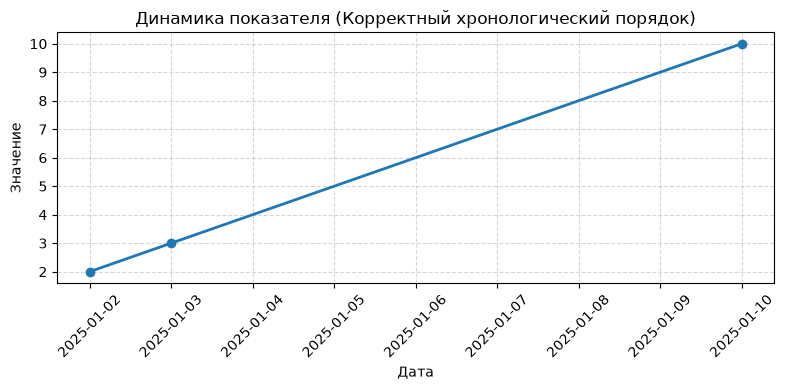

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Исходные данные с ошибкой формата
df = pd.DataFrame({
    "date": ["2025-01-10", "2025-01-2", "2025-01-3"],
    "value": [10, 2, 3]
})

# 2. Исправление: приведение строки к datetime
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# 3. Оформление графика
plt.figure(figsize=(8, 4))
plt.plot(df["date"], df["value"], marker="o", color="#1f77b4", linewidth=2)
plt.title("Динамика показателя (Корректный хронологический порядок)")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Часть 1. Аналитическая визуализация витрины (Mart)

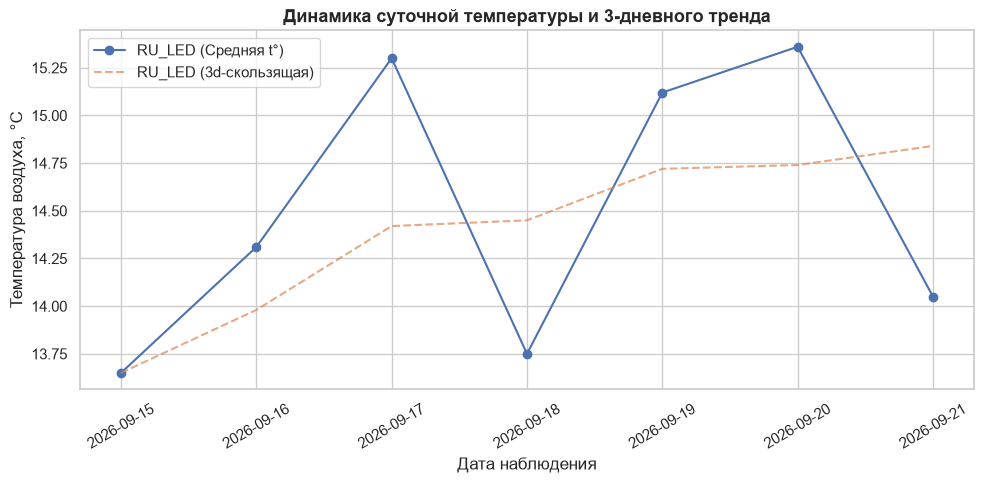

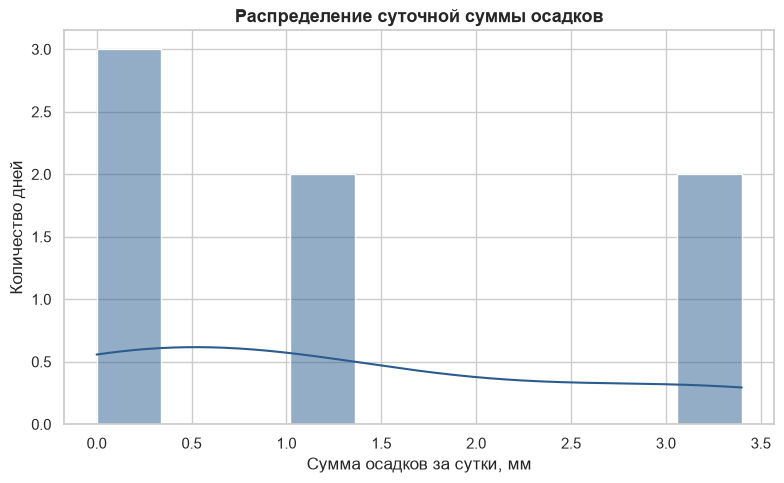

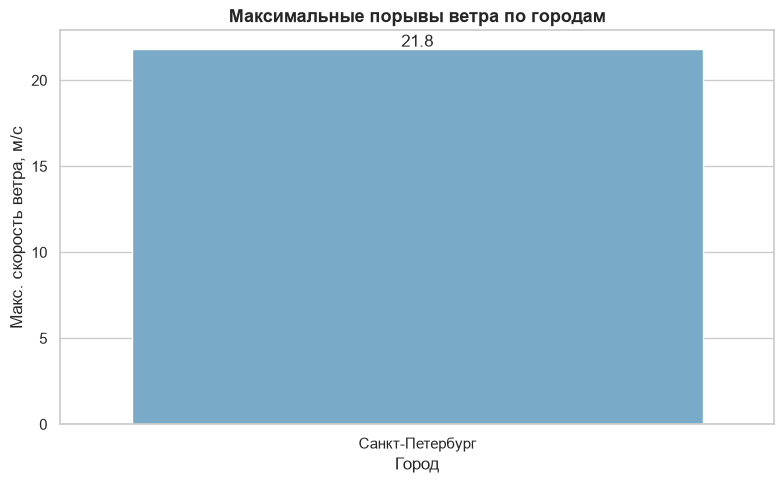

In [3]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

mart_dir = PROJECT_ROOT / "data" / "mart" / "variant_02"
mart_files = sorted(list(mart_dir.glob("mart_daily_*.csv")))
if not mart_files:
    raise FileNotFoundError("Файлы витрины mart_daily_*.csv не найдены.")

df = pd.read_csv(mart_files[-1])
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by=["city_id", "date"]).reset_index(drop=True)

# 1. Временной ряд
plt.figure(figsize=(10, 5))
for city in df["city_id"].unique():
    city_data = df[df["city_id"] == city]
    plt.plot(city_data["date"], city_data["temp_mean"], marker="o", label=f"{city} (Средняя t°)")
    if "temp_mean_rolling_3d" in city_data.columns:
        plt.plot(city_data["date"], city_data["temp_mean_rolling_3d"], linestyle="--", alpha=0.7, label=f"{city} (3d-скользящая)")
plt.title("Динамика суточной температуры и 3-дневного тренда", fontsize=13, weight="bold")
plt.xlabel("Дата наблюдения")
plt.ylabel("Температура воздуха, °C")
plt.legend(loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "week7_timeseries.png", dpi=300)
plt.show()

# 2. Распределение
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="precip_sum", bins=10, kde=True, color="#2b5c8f")
plt.title("Распределение суточной суммы осадков", fontsize=13, weight="bold")
plt.xlabel("Сумма осадков за сутки, мм")
plt.ylabel("Количество дней")
plt.tight_layout()
plt.savefig(FIG_DIR / "week7_distribution.png", dpi=300)
plt.show()

# 3. Ранжирование
plt.figure(figsize=(8, 5))
city_stats = df.groupby("city_name")["wind_speed_max"].max().sort_values(ascending=False).reset_index()
ax = sns.barplot(
    data=city_stats, 
    x="city_name", 
    y="wind_speed_max", 
    hue="city_name",      # Добавлено: привязка цвета к категориям
    palette="Blues_r", 
    legend=False          # Добавлено: скрываем лишнюю легенду
)
plt.title("Максимальные порывы ветра по городам", fontsize=13, weight="bold")
plt.xlabel("Город")
plt.ylabel("Макс. скорость ветра, м/с")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIG_DIR / "week7_ranking.png", dpi=300)
plt.show()